1DECISION TREE

Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

Tasks:

1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [2]:
import pandas as pd

In [3]:
df=pd.read_excel(r"C:\Users\ACRE\Downloads\heart_disease.xlsx",sheet_name=1)

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.shape


(908, 13)

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


observation 
data set has 908 row and 13 column 
datatype are categorical and numarical both 

2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [8]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df[df.duplicated]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
765,58,Male,non-anginal,150,219,False,st-t abnormality,118,True,0.0,downsloping,fixed defect,2


observation
data set has null values 
data set also have duplicate values 

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df[df.duplicated]


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num


In [13]:
df.reset_index(drop=True,inplace=True)

In [14]:
df['oldpeak']=df['oldpeak'].fillna(df['oldpeak'].median())

In [15]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

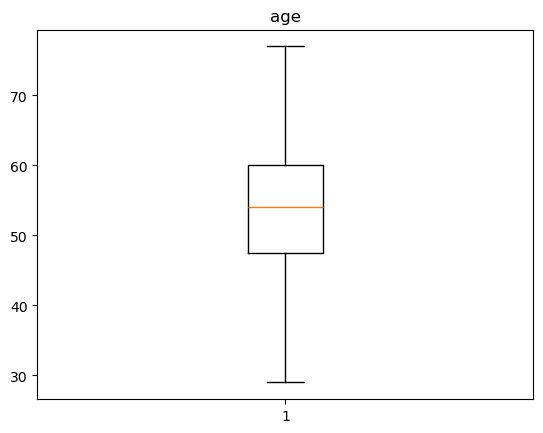

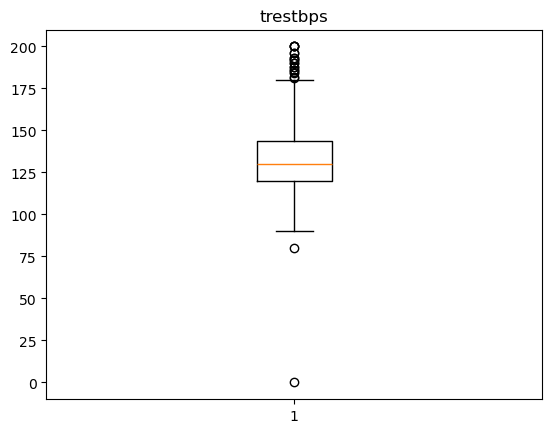

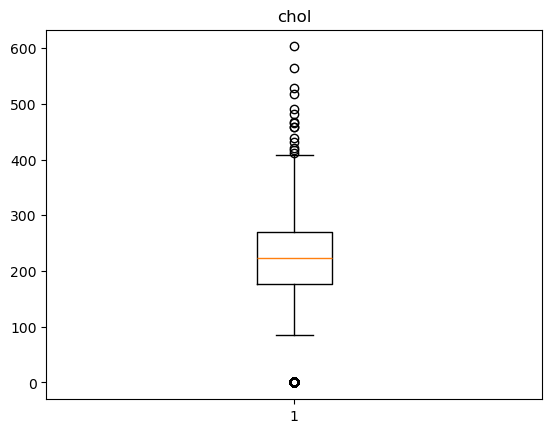

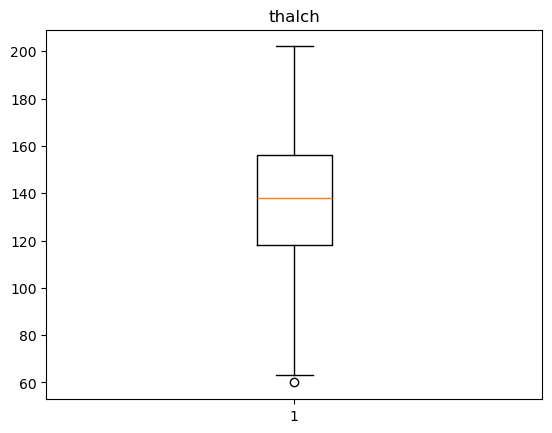

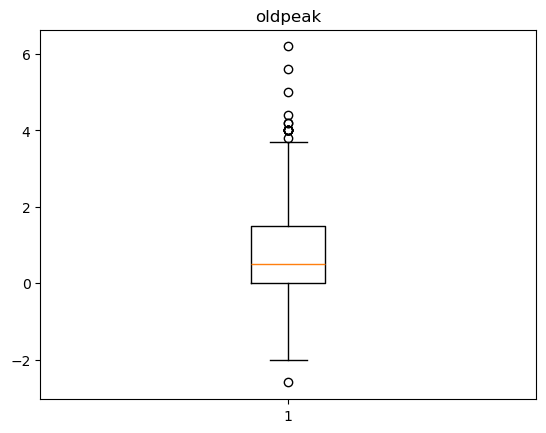

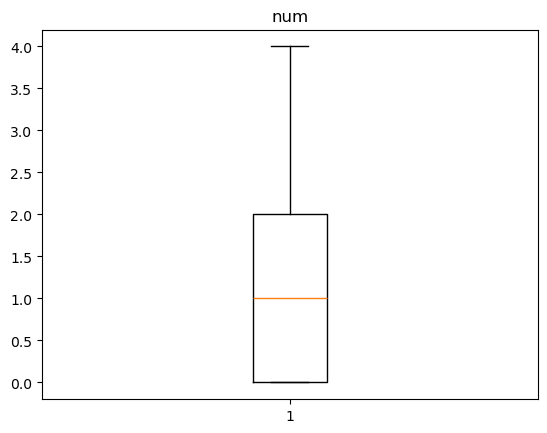

In [16]:
#to detect outlier
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number').columns:
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [17]:
Q1=df['trestbps'].quantile(0.25)

In [18]:
Q3=df['trestbps'].quantile(0.75)

In [19]:
IQR=Q1-Q3

In [20]:
UE = Q3 + 1.5 *(IQR)

LE= Q1 - 1.5*(IQR)

In [21]:
df[df['trestbps']>UE]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
903,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
904,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
905,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,0.5,downsloping,reversable defect,4


In [22]:
df.loc[df['trestbps']>UE,'trestbps']=UE

In [23]:
df[df['trestbps']<LE]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,108,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,108,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,108,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,108,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,108,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,Male,asymptomatic,108,0,False,normal,120,False,1.5,upsloping,normal,4
903,62,Male,asymptomatic,108,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
904,56,Male,non-anginal,108,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
905,56,Male,non-anginal,108,208,True,st-t abnormality,105,TURE,0.5,downsloping,reversable defect,4


In [24]:
df.loc[df['trestbps']<LE,'trestbps']=LE

In [25]:
df[df['chol']>UE]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,156,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,156,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,156,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,156,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,156,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,61,Male,asymptomatic,156,287,True,lv hypertrophy,150,True,2.0,downsloping,reversable defect,4
901,62,Male,asymptomatic,156,254,True,st-t abnormality,108,True,3.0,flat,normal,4
903,62,Male,asymptomatic,156,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,156,208,True,st-t abnormality,105,TURE,0.5,downsloping,reversable defect,4


In [26]:
df.loc[df['chol']>UE,'chol']=UE

In [27]:
df[df['chol']<LE]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,156,108,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,156,108,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,156,108,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,156,108,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,156,108,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,Male,asymptomatic,156,0,False,normal,120,False,1.5,upsloping,normal,4
903,62,Male,asymptomatic,156,108,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
904,56,Male,non-anginal,156,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
905,56,Male,non-anginal,156,108,True,st-t abnormality,105,TURE,0.5,downsloping,reversable defect,4


In [28]:
x=df.drop('num',axis=1)
y=df['num']

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

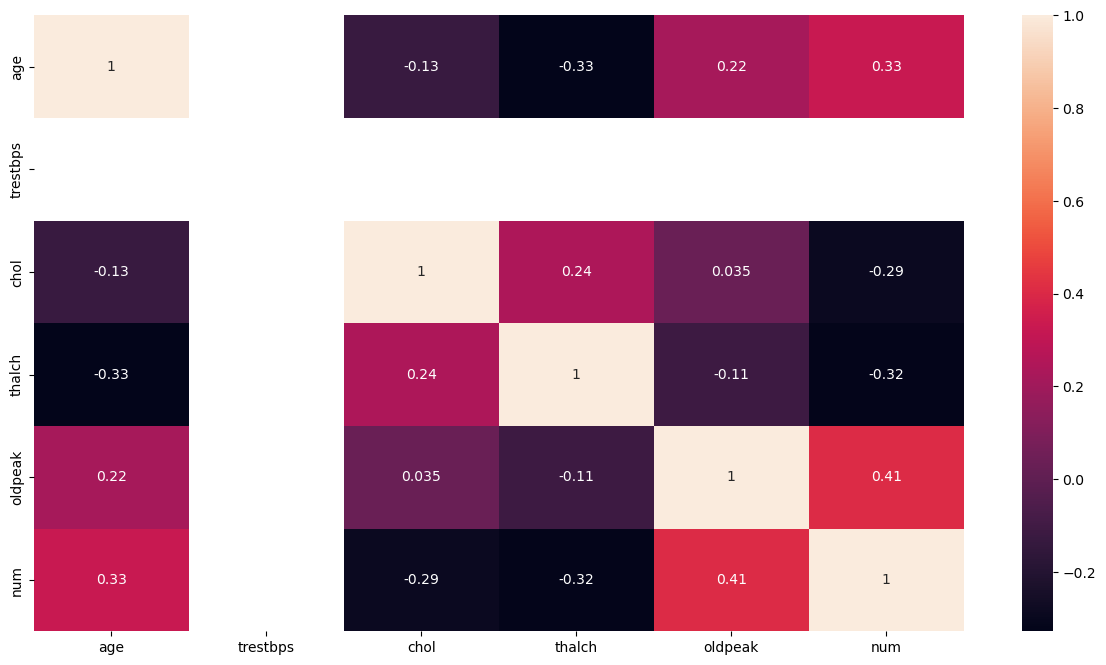

In [30]:
corr=df.select_dtypes(include='number').corr()

plt.figure(figsize=(15,8))
sns.heatmap(corr,annot=True)

3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [31]:
x=df.drop('num',axis=1)
y=df['num']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       907 non-null    int64  
 1   sex       907 non-null    object 
 2   cp        907 non-null    object 
 3   trestbps  907 non-null    int64  
 4   chol      907 non-null    int64  
 5   fbs       907 non-null    bool   
 6   restecg   907 non-null    object 
 7   thalch    907 non-null    int64  
 8   exang     907 non-null    object 
 9   oldpeak   907 non-null    float64
 10  slope     907 non-null    object 
 11  thal      907 non-null    object 
 12  num       907 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.0+ KB


obsevation 
sex,cp,restecg,exang,slope,thal column are catagorical.

In [35]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [36]:
df['cp'].unique() 

array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)

In [37]:
df['restecg'].unique() 

array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)

In [38]:
df['exang'].unique() 

array([False, True, 'FALSE', 'TURE'], dtype=object)

In [39]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping'], dtype=object)

In [40]:
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

obsevation 
1.in exang column their is inconsistance text 2.and 'sex','cp','restecg','slope','thal are catagorical

In [41]:
df['exang']=df['exang'].replace({'TURE':True,'FALSE':False,})

C:\Users\ACRE\AppData\Local\Temp\ipykernel_5360\1044635932.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang']=df['exang'].replace({'TURE':True,'FALSE':False,})


In [42]:
df['exang'].unique() 

array([False,  True])

In [43]:
df=pd.get_dummies(df,columns=['sex','cp','restecg','slope','thal','exang'],drop_first=True,dtype='int')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       907 non-null    int64  
 1   trestbps                  907 non-null    int64  
 2   chol                      907 non-null    int64  
 3   fbs                       907 non-null    bool   
 4   thalch                    907 non-null    int64  
 5   oldpeak                   907 non-null    float64
 6   num                       907 non-null    int64  
 7   sex_Male                  907 non-null    int64  
 8   cp_atypical angina        907 non-null    int64  
 9   cp_non-anginal            907 non-null    int64  
 10  cp_typical angina         907 non-null    int64  
 11  restecg_normal            907 non-null    int64  
 12  restecg_st-t abnormality  907 non-null    int64  
 13  slope_flat                907 non-null    int64  
 14  slope_upsl

In [45]:
df.isnull().sum()

age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
oldpeak                     0
num                         0
sex_Male                    0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
exang_True                  0
dtype: int64

4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [46]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split

In [47]:
x=df.drop('num',axis=1)
y=df['num']

In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [49]:
dt=DecisionTreeClassifier()

In [50]:
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [51]:
y_pred_train = dt.predict(x_train)
y_pred_test = dt.predict(x_test)

from sklearn.metrics import accuracy_score, log_loss
training_accuracy  = accuracy_score(y_train,y_pred_train)
test_accuracy  = accuracy_score(y_test,y_pred_test)

import numpy as np
print("trianing accuracy:", np.round(training_accuracy,2))
print("test accuracy:", np.round(test_accuracy,2))

trianing accuracy: 1.0
test accuracy: 0.45


5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [52]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini')

# Set up ShuffleSplit cross-validator
from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split = ShuffleSplit(n_splits=200, test_size=0.3, random_state=42)

# Perform cross-validation and collect both train and test scores
cv_results = cross_validate(model, x, y, cv=shuffle_split, scoring='accuracy', return_train_score=True)

# Extract train and test scores
train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

# Show individual scores and their means
print("cross validation: test accuracy:" , np.round(train_scores.mean(),2))
print("cross validation: test accuracy:" , np.round(test_scores.mean(),2))

cross validation: test accuracy: 1.0
cross validation: test accuracy: 0.47


6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features

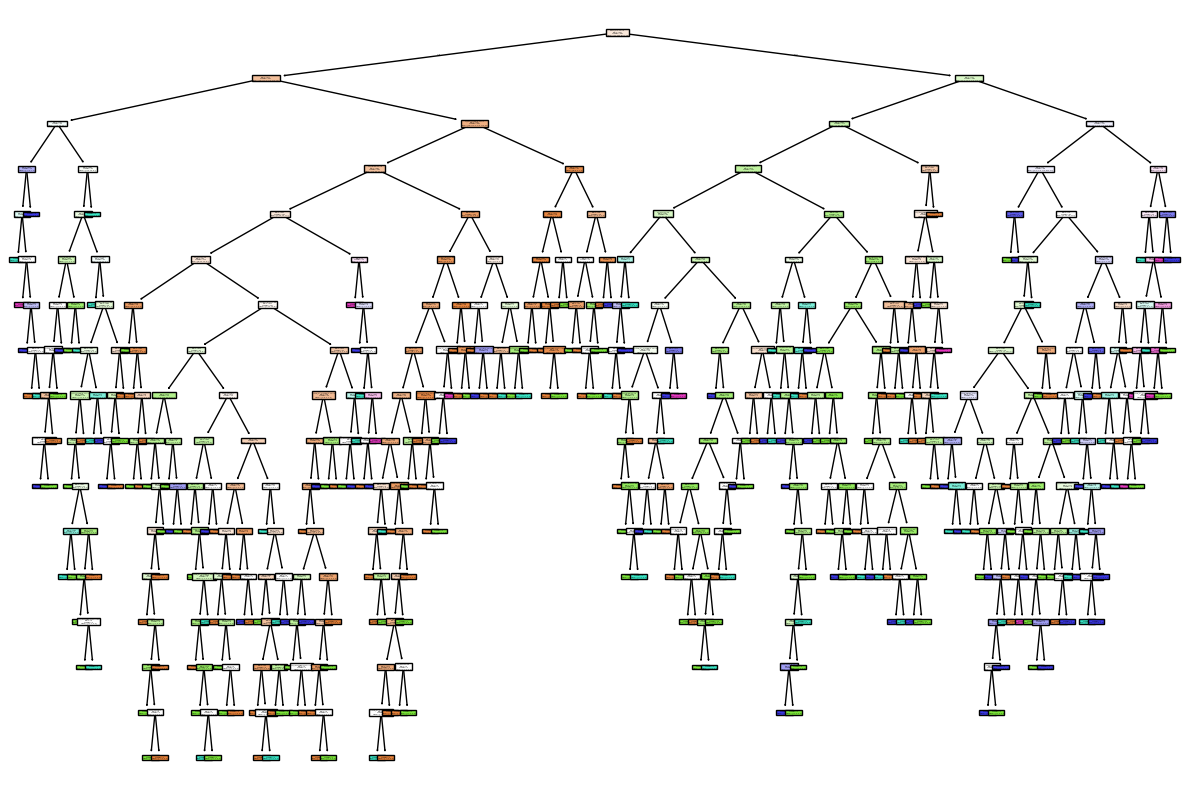

In [54]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(
    dt,
    filled=True,
    feature_names=x.columns,
)
plt.show()

Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?

In [ ]:
Important hyperparameters include max_depth, min_samples_split, and min_samples_leaf, which control tree complexity.
Proper tuning helps avoid overfitting and improves model performance.

In [ ]:
Label encoding assigns numbers to categories but may introduce order, while one-hot encoding creates binary columns and avoids
any ordinal relationship.